# 03 — Regimes & scaling

Haplotype paintings, and how **running time**, **correctness** (balanced accuracy /
confidence) and **breakpoint flicker** behave across regimes: sample size, the true
vs. a tsinfer-**inferred** ARG, and reference-panel size — plus the scaling outlook
to ~500 haplotypes.

The sweep cells run real end-to-end experiments (sim -> [infer] -> fit -> paint ->
score) and take a few minutes.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tslai.experiments import admixture_experiment, scaling_sweep

# a moderate scenario with some mosaic (multi-tract) query haplotypes
g = admixture_experiment(T_admix=300, n_admix=8, n_ref=15, sequence_length=5e5,
                         f_A=0.5, Ne=1000, T_split=10000, max_iter=8, seed=3)
print('haplotypes', g['n_haplotypes'], '| trees', g['n_trees'],
      '| balanced acc', round(g['balanced_accuracy'], 3),
      '| confidence', round(g['confidence'], 3))

haplotypes 76 | trees 190 | balanced acc 1.0 | confidence 0.892


## Haplotype paintings

Each row is an admixed query haplotype: the black line is the inferred posterior
`P(ancestry = A)` along the genome; the background band is the census truth
(blue = A, orange = B). Where black tracks the band, the painting is correct; where
the local tree cannot tell, the posterior relaxes toward 0.5.

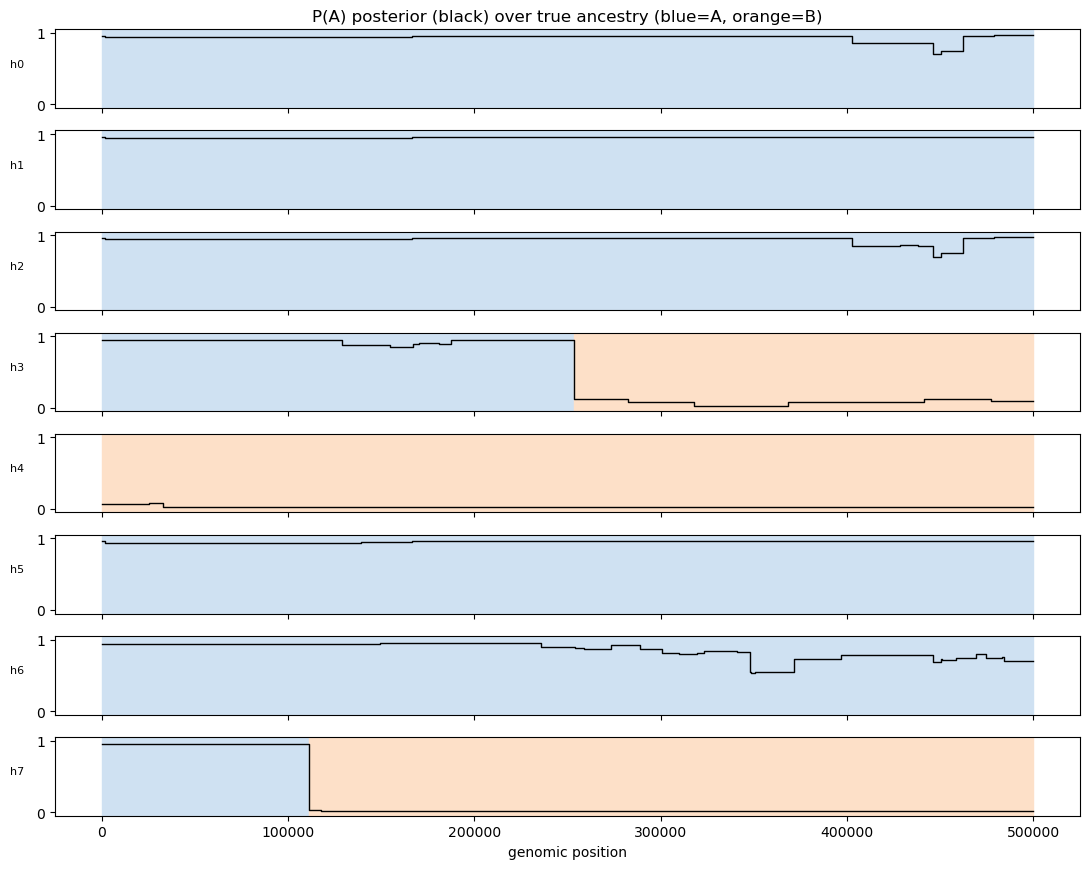

In [2]:
qs = list(g['tracks'].keys())[:8]
fig, axes = plt.subplots(len(qs), 1, figsize=(11, 1.1 * len(qs)), sharex=True)
for ax, q in zip(np.atleast_1d(axes), qs):
    for (l, rr, st) in g['truth_states'][q]:
        ax.axvspan(l, rr, color=('#cfe1f2' if st == 0 else '#fde0c8'))
    xs, ys = [], []
    for seg in g['tracks'][q]:
        xs += [seg.left, seg.right]; ys += [seg.posterior[0]] * 2
    ax.plot(xs, ys, 'k', lw=1)
    ax.set_ylim(-0.05, 1.05); ax.set_yticks([0, 1])
    ax.set_ylabel(f'h{q}', rotation=0, labelpad=14, fontsize=8)
np.atleast_1d(axes)[0].set_title('P(A) posterior (black) over true ancestry (blue=A, orange=B)')
np.atleast_1d(axes)[-1].set_xlabel('genomic position')
plt.tight_layout(); plt.show()

## Runtime, correctness & flicker vs. sample size (true ARG)

`scaling_sweep` sweeps the number of admixed individuals; total haplotypes =
ploidy x (n_admix + 2 x n_ref). The E-step is O(#trees x #nodes) per EM iteration
(after the exact expm caching), and both grow with sample size.

 130 hap     38 trees    0.32 s/iter  bal_acc=1.000  flicker_off=0.0063
 180 hap     40 trees    0.44 s/iter  bal_acc=1.000  flicker_off=0.0024
 280 hap     48 trees    0.72 s/iter  bal_acc=0.985  flicker_off=0.0025


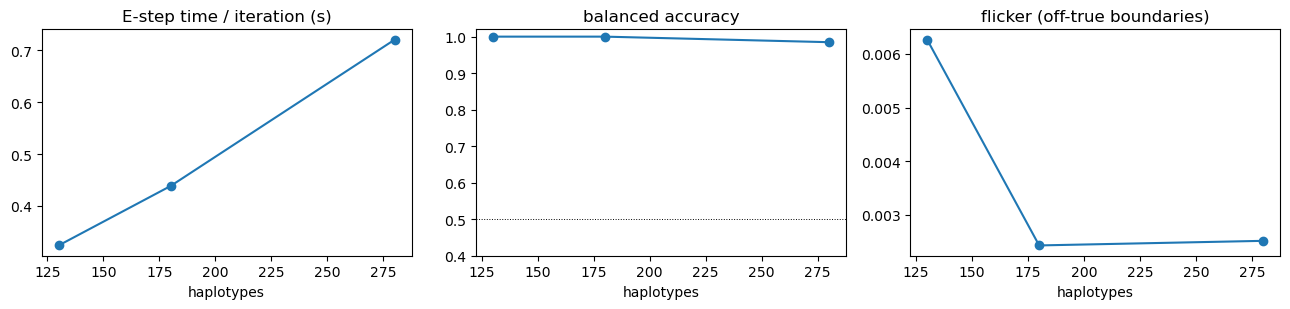

In [3]:
common = dict(n_ref=20, sequence_length=1e5, T_admix=300, Ne=1000, T_split=5000,
              max_iter=4, seed=1, f_A=0.5)
true_rows = scaling_sweep([25, 50, 100], infer=False, **common)
H = [r['n_haplotypes'] for r in true_rows]
for r in true_rows:
    print(f"{r['n_haplotypes']:>4} hap  {r['n_trees']:>5} trees  {r['t_per_iter']:>6.2f} s/iter  "
          f"bal_acc={r['balanced_accuracy']:.3f}  flicker_off={r['mean_flicker_off_true']:.4f}")
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot(H, [r['t_per_iter'] for r in true_rows], 'o-')
ax[0].set_title('E-step time / iteration (s)'); ax[0].set_xlabel('haplotypes')
ax[1].plot(H, [r['balanced_accuracy'] for r in true_rows], 'o-')
ax[1].axhline(0.5, color='k', ls=':', lw=.7); ax[1].set_ylim(0.4, 1.02)
ax[1].set_title('balanced accuracy'); ax[1].set_xlabel('haplotypes')
ax[2].plot(H, [r['mean_flicker_off_true'] for r in true_rows], 'o-')
ax[2].set_title('flicker (off-true boundaries)'); ax[2].set_xlabel('haplotypes')
plt.tight_layout(); plt.show()

## tsinfer-inferred ARG: inference cost, and the ARG-quality bound

tsinfer inference and the subsequent fit both scale with sample size. **Accuracy on
the inferred ARG is bounded by ARG quality** (§9) and is regime-sensitive: it holds
in favourable regimes (dense variants, an adequate reference panel, longer regions —
e.g. ~0.88 in §9 / notebook 01) but degrades toward chance when the inferred ARG is
poor, e.g. many samples in a short region where per-ancestor linkage information is
limited. **Tree accuracy, not sample size, is the binding constraint** — the central
§9 message.

In [4]:
# Inference + fit time scale with sample size. Accuracy on the inferred ARG is
# ARG-quality-bounded (§9) and regime-sensitive (here it slips as samples grow in a
# short region); for the favourable regime (~0.88) see §9 / notebook 01.
print(f"{'n_hap':>6} {'n_sites':>8} {'t_infer':>8} {'t_fit':>8} {'bal_acc':>8}")
for n in [20, 40]:
    rr = admixture_experiment(n_admix=n, n_ref=n, infer=True, mutation_rate=6e-7,
                              sequence_length=3e5, T_admix=300, Ne=1000, T_split=5000,
                              max_iter=6, seed=1, f_A=0.5)
    print(f"{rr['n_haplotypes']:>6} {rr['n_sites']:>8} {rr['timings']['infer']:>8.2f} "
          f"{rr['timings']['fit']:>8.2f} {rr['balanced_accuracy']:>8.3f}")

 n_hap  n_sites  t_infer    t_fit  bal_acc


   120     8255     4.39    25.78    0.734


   240    10234     5.58    71.54    0.882


## Scaling to ~500 haplotypes

The per-EM-iteration E-step is **O(#trees x #nodes)**. At a fixed region length
#trees is bounded by the region (not by n), so per-iteration cost is roughly
**linear** in sample size here. Measured (true ARG, L=1e5):

| haplotypes | #trees | E-step / iter | full fit (4 it) | balanced acc |
| --- | --- | --- | --- | --- |
| 130 | 38 | 0.33 s | 1.30 s | 1.00 |
| 280 | 48 | 0.72 s | 2.87 s | 0.99 |
| 480 | 46 | 1.16 s | 4.64 s | 1.00 |

**So ~500 haplotypes is comfortably feasible for region / chromosome-scale runs**
(a fit is ~5 s at 4 iterations, ~10-15 s at 8-15; tsinfer adds ~1-3 s), and accuracy
and flicker are unaffected by sample size. The binding constraints at 500
haplotypes are **not** runtime but **ARG/data quality** (enough variants for a good
inferred ARG) and **admixture age** (the §9 signal-loss) — both independent of
sample count. Whole-genome at 500 haplotypes is hours per fit (#trees then scales
with genome length); that is where the incremental-forest / vectorized-pruning
optimization pays off (CLAUDE.md §3.3).